# <font color="red">=====================Circular plots of FC matrices=========================

## <font color="green">======================================I tested the within hemisphere and between hemispheres by creating just a few lines, counting the number of connections======================================

In [6]:
import numpy as np
import os
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display, Image, SVG
import pandas as pd
from matplotlib import rcParams

# Set the font to Arial
rcParams['font.family'] = 'Times New Roman'
rcParams['svg.fonttype'] = 'none'
from matplotlib.pyplot import colorbar, polar
import matplotlib.patheffects as pe
from nilearn import plotting, connectome
from sympy import symbols, Eq, solve
from mne_connectivity.viz import plot_connectivity_circle
from mne.viz import circular_layout
import sys
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
sys.path.append("/Users/aeed/Dropbox/SCRIPTS/functional_connectivity")
from FC_functions import combine_list, average_csv_list, plot_pcolor_map, plot_unsym_conn_mat, reduce_conn_matrix,create_flattened_csv, plot_conn_rows, average_df_csv_list, plot_unsym_conn_mat, quadrant_means_to_2x2, quadrant_RMSE_to_2x2, plot_connectivity_circle2


from mne.utils.check import _validate_type
from itertools import cycle
from mne.viz.utils import _get_cmap, plt_show
from functools import partial
from mne.viz.circle import _plot_connectivity_circle_onpick

In [10]:
# atlas labels
csv_12_labels = "/Volumes/Crucial_4TB/Brown_Vaccht/transcription_trial/atlases/Atlas_res_50_set_id_2_ROIs_12_bilateral_labels.csv"
labels_12_df = pd.read_csv(csv_12_labels).sort_values("label_value")
labels_12_list = labels_12_df["acronym"].tolist()
no_roi = 12

In [11]:
# read the txt file, and get the number of lines and that will be the number of subjects
orig_dir="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI"
conn = "correlation"
PBS_file = f"{orig_dir}/{conn}/PBS_ses-01_{conn}.txt"
PFF_file = f"{orig_dir}/{conn}/PFF_ses-01_{conn}.txt"
with open(PBS_file, 'r') as f:
    lines = f.readlines()
    num_subjects = len(lines)
PBS_n_subjects = num_subjects

with open(PFF_file, 'r') as f:
    lines = f.readlines()
    num_subjects = len(lines)

PFF_n_subjects = num_subjects

In [12]:

PBS_s1_correlation, PBS_s1_stdv = average_df_csv_list(
    "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_ses-01_correlation.txt",
    no_regions=no_roi)
PBS_s1_correlation_quadrant = quadrant_RMSE_to_2x2(PBS_s1_correlation)


PFF_s1_correlation, PFF_s1_stdv = average_df_csv_list(
    "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_ses-01_correlation.txt",
    no_regions=no_roi)
PFF_s1_correlation_quadrant = quadrant_RMSE_to_2x2(PFF_s1_correlation)

# percentage change + clipping the values between -200 and + 200
# percentage change + clipping the values between -200 and + 200 between PBS and PFF
PFF_vs_PBS_correlation = (PFF_s1_correlation - PBS_s1_correlation) / ((PFF_s1_correlation)) * 100
# PFF_vs_PBS_correlation = np.clip(PFF_vs_PBS_correlation, -200, 200)
PFF_vs_PBS_correlation_quadrant = quadrant_RMSE_to_2x2(PFF_vs_PBS_correlation)



# <font color="red">======================================Circular figure======================================<font>

In [33]:
Q1 = PFF_s1_correlation[:12, :12]
Q2 = PFF_s1_correlation[12:, :12]

Q1_s1 = PFF_s1_correlation[12:, :12]
Q = Q1[Q1 > 0.02]
Q.shape

np.allclose(Q2, Q2.T, )
import numpy as np
from nilearn import plotting, connectome


def keep_top_pos_neg_directed(C, frac=0.10, zero_diag=True):
    C = np.asarray(C)
    assert C.ndim == 2 and C.shape[0] == C.shape[1]
    N = C.shape[0]

    out = np.zeros_like(C)

    # off-diagonal mask
    mask_off = ~np.eye(N, dtype=bool)
    vals = C[mask_off]

    pos = vals[vals > 0]
    neg = vals[vals < 0]

    pos_thr = np.percentile(pos, 100 * (1 - frac)) if pos.size else np.inf
    neg_thr = np.percentile(neg, 100 * frac) if neg.size else -np.inf

    keep = (C >= pos_thr) | (C <= neg_thr)
    keep &= mask_off  # never keep diagonal

    out[keep] = C[keep]

    if not zero_diag:
        np.fill_diagonal(out, np.diag(C))

    return out, pos_thr, neg_thr


C_thr, pos_thr, neg_thr = keep_top_pos_neg_directed(Q1, frac=0.10, )
C_thr.shape
C_thr
labels_one_hemi = labels_12_list[:12]
label_colors = [
    "#70FF71",
    "#70FF71",
    "#9AD2BD",
    "#9AD2BD",
    "#7ED04B",
    "#7ED04B",
    "#8ADA87",
    "#8ADA87",
    "#98D6F9",
    "#98D6F9",
    "#8599CC",
    "#8599CC",
    "#FF7080",
    "#FF7080",
    "#E64438",
    "#E64438",
    "#FF64FF",
    "#FF64FF",
    "#FF9B88",
    "#FF9B88",
    "#FF9BCD",
    "#FF9BCD",
    "#F0F080",
    "#F0F080",
]
labels_colors_one_hemi = ["#70FF71",
                          "#9AD2BD",
                          "#7ED04B",
                          "#8ADA87",
                          "#98D6F9",
                          "#8599CC",
                          "#FF7080",
                          "#E64438",
                          "#FF64FF",
                          "#FF9B88",
                          "#FF9BCD",
                          "#F0F080", ]
# First, we reorder the labels based on their location in the left hemi
label_names = labels_one_hemi
# lh_labels = [name for name in label_names if name.startswith("L")]
#
#
# # For the right hemi
# rh_labels =  ["R_" + label[2:]  for label in lh_labels]
#
# # Save the plot order and create a circular layout
node_order = list()
#
# node_order.extend(lh_labels)
# node_order.extend(rh_labels[::-1])
node_order.extend(label_names)
# node_order.extend(rh_labels[::-1])


node_angles = circular_layout(
    label_names, node_order, start_pos=90, group_boundaries=[0, len(label_names) / 2], group_sep=0, start_between=True
)

vmax = 0.1
vmin = -0.1
n_lines = None
linewidths_conn = 5
colormap = "coolwarm"
title_font = 14
title_y_pos = 1
title_x_pos = 0.5

# colorbar hyperparameters
colorbar_pos = (0.2, 0.5)
colorbar_title_pos1 = -0.08
colorbar_title_pos2 = 22

mask_value = 0

fig, axs = plt.subplots(2, 2, figsize=(20, 20), facecolor="white", subplot_kw=dict(polar=True))
fig.suptitle('circular trial', fontsize=20, color="black")
fig.subplots_adjust(hspace=0.3, wspace=0.3)  # Adjust horizontal and vertical spacing
# remove any value bigger than 0.05
# stats_PBS_s1_vs_s2_fdrp_c2[stats_PBS_s1_vs_s2_fdrp_c2 > 0.05] = mask_value
Q_lower = np.tril(Q1)
plot_connectivity_circle2(
    Q1,
    label_names,
    n_lines=n_lines,
    node_angles=node_angles,
    node_colors=labels_colors_one_hemi,
    ax=axs[0, 0],
    colormap=colormap,
    vmin=vmin,
    vmax=vmax,
    linewidth=linewidths_conn,
    node_height=1,
    colorbar_pos=colorbar_pos,
    show=False,
    facecolor="white",
    textcolor="black",
    min_alpha=0.05,
    max_alpha=0.5

)



plot_connectivity_circle2(
    Q2,
    label_names,
    n_lines=n_lines,
    node_angles=node_angles,
    node_colors=labels_colors_one_hemi,
    ax=axs[0, 1],
    colormap=colormap,
    vmin=vmin,
    vmax=vmax,
    linewidth=linewidths_conn,
    node_height=1,
    colorbar_pos=colorbar_pos,
    show=False,
    facecolor="white",
    textcolor="black",
    alpha=1
)

plot_connectivity_circle2(
    Q1_s1,
    label_names,
    n_lines=n_lines,
    node_angles=node_angles,
    node_colors=labels_colors_one_hemi,
    ax=axs[1, 1],
    colormap=colormap,
    vmin=vmin,
    vmax=vmax,
    linewidth=linewidths_conn,
    node_height=1,
    colorbar_pos=colorbar_pos,
    show=False,
    facecolor="white",
    textcolor="black",
    # alpha_mat=Q1,
    # min_alpha=0,
    # max_alpha=1
)



Q_test = np.zeros_like(Q1)
Q_test[8, 0] = 0.7  # pick a specific pair
Q_test[9, 8] = -0.7  # pick a specific pair
plot_connectivity_circle2(
    Q_test,
    label_names,
    n_lines=1,
    node_angles=node_angles,
    node_colors=labels_colors_one_hemi,
    ax=axs[1, 0],
    colormap=colormap,
    vmin=-0.5,
    vmax=0.5,
    # linewidth=linewidths_conn,
    node_height=1,
    colorbar_pos=colorbar_pos,
    show=False,
    facecolor="white",
    textcolor="black",
    directed=False
    # alpha=0.0
)


ValueError: operands could not be broadcast together with shapes (0,12) (12,0) 

In [17]:
label_names = labels_22_list
lh_labels = [name for name in label_names if name.startswith("L")]


# For the right hemi
rh_labels =  ["R_" + label[2:]  for label in lh_labels]

# Save the plot order and create a circular layout
node_order = list()

node_order.extend(lh_labels)
node_order.extend(rh_labels[::-1])


node_angles = circular_layout(
    label_names, node_order, start_pos=90, group_boundaries=[0, len(label_names) / 2], group_sep=20, start_between=True
)

NameError: name 'labels_22_list' is not defined

In [18]:
left_names = [f"L_{name[2:]}" for name in labels_one_hemi]
right_names = [f"R_{name[2:]}" for name in labels_one_hemi]
nL, nR = Q2.shape
A = np.zeros((nL + nR, nL + nR))
A[:nL, nL:] = Q2                      # Left -> Right block
label_names = left_names + right_names
node_names = left_names + right_names
node_order = list()

node_order.extend(left_names)
node_order.extend(right_names[::-1])
n_lines = len(label_names)

edge_mask = np.zeros_like(A, dtype=bool)
edge_mask[:nL, nL:] = True                # only draw L->R edges

node_angles = np.concatenate([
    np.linspace(90, 270, nL, endpoint=False),   # degrees
    np.linspace(-90, 90, nR, endpoint=False),
])
node_angles = circular_layout(
    label_names, node_order, start_pos=90, group_boundaries=[0, len(label_names) / 2], group_sep=40, start_between=True
)

fig, ax = plot_connectivity_circle2(
    con=A,
    node_names=node_names,
    node_angles=node_angles,
    node_colors=labels_colors_one_hemi * 2,
    directed=True,
    edge_mask=edge_mask,
    facecolor="white",
    textcolor="black",
    colormap='coolwarm',
    n_lines=None,
    vmin=-0.1,
    vmax=0.1,
    alpha_mat=A,
    min_alpha=0.01,
    max_alpha=1,
    # alpha_vmin=0.01,
    # alpha_vmax=0.1,
    thickness_mat=A,
    min_thickness=0.01,
    max_thickness=10,
    # thickness_vmin=0.01,
    # thickness_vmax=0.1,


)
fig.savefig("00015_FC_R_then_L_atlasses_circular.svg")

NameError: name 'labels_one_hemi' is not defined

In [19]:
plt.figure(figsize=(10, 10))
plt.imshow(A, cmap="coolwarm")

plt.colorbar()
# set x and y ticks
plt.xticks(ticks=np.arange(len(node_names)), labels=node_names, rotation=90)
plt.yticks(ticks=np.arange(len(node_names)), labels=node_names)
# set colorbar range
plt.clim(-0.1, 0.1)
plt.title("Adjacency used for circle plot")
plt.show()

NameError: name 'A' is not defined

<Figure size 1000x1000 with 0 Axes>

In [20]:
node_angles

NameError: name 'node_angles' is not defined

In [21]:
!pwd

/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/LSFM_MRI/00010_FC_12_atlases


In [22]:
# count how many values > 0
np.sum(Q2 > 0)

NameError: name 'Q2' is not defined

In [23]:
np.sum(Q2 < 0)

NameError: name 'Q2' is not defined

In [24]:
A

NameError: name 'A' is not defined

In [25]:
Q2

NameError: name 'Q2' is not defined

In [26]:
(0.139 * 5 )/ 0.195998

3.5459545505566386

In [27]:
A

NameError: name 'A' is not defined

In [28]:
# test it

A_test = np.zeros_like(A)
A_test[3, 18] = 0.0203   # pick a specific Left->Right pair you know


NameError: name 'A' is not defined

In [29]:
A_test

NameError: name 'A_test' is not defined

In [30]:

fig, ax = plot_connectivity_circle2(
    con=A_test,
    node_names=node_names,
    node_angles=node_angles,
    node_colors=labels_colors_one_hemi * 2,
    directed=True,
    edge_mask=edge_mask,
    facecolor="white",
    textcolor="black",
    colormap='jet',
    n_lines=1,
    vmin=-.05,
    vmax=0.05,
    alpha_mat=A,
    min_alpha=0.6,
    max_alpha=0.9,
    alpha_vmin=0.01,
    alpha_vmax=0.1,
    thickness_mat=A_test,
    min_thickness=0.00,
    max_thickness=1,
    thickness_vmin=0.01,
    thickness_vmax=0.1,


)
fig.savefig("00015_FC_R_then_L_atlasses_circular_test.svg")

NameError: name 'A_test' is not defined

# <font color="red">======================================Create nested circular figures======================================<font>

NameError: name 'Q_test' is not defined

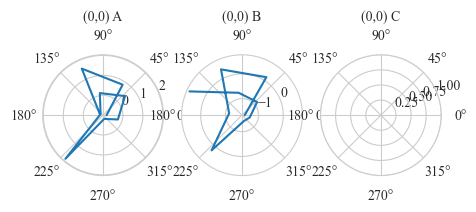

In [31]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(18, 10))
outer = GridSpec(2, 3, figure=fig, wspace=0.25, hspace=0.25)

for i in range(2):
    for j in range(3):
        inner = outer[i, j].subgridspec(1, 3, wspace=0.15)

        ax1 = fig.add_subplot(inner[0], polar=True)
        ax2 = fig.add_subplot(inner[1], polar=True)
        ax3 = fig.add_subplot(inner[2], polar=True)

        ax1.set_title(f"({i},{j}) A", fontsize=10)
        ax2.set_title(f"({i},{j}) B", fontsize=10)
        ax3.set_title(f"({i},{j}) C", fontsize=10)

        # for ax in (ax1, ax2, ax3):
        #     ax.plot(np.random.randn(10))
        #     ax.grid(False)

        ax1.plot(np.random.randn(10))
        ax2.plot(np.random.randn(10))
        plot_connectivity_circle2(
        Q_test,
        label_names,
        n_lines=1,
        node_angles=node_angles,
        node_colors=labels_colors_one_hemi,
        ax=ax3,
        colormap=colormap,
        vmin=-0.5,
        vmax=0.5,
        # linewidth=linewidths_conn,
        node_height=1,
        colorbar_pos=colorbar_pos,
        show=False,
        facecolor="white",
        textcolor="black",
        directed=False
        # alpha=0.0
    )

In [36]:
labels_one_hemi = labels_12_list[:12]
label_colors = [
    "#70FF71",
    "#70FF71",
    "#9AD2BD",
    "#9AD2BD",
    "#7ED04B",
    "#7ED04B",
    "#8ADA87",
    "#8ADA87",
    "#98D6F9",
    "#98D6F9",
    "#8599CC",
    "#8599CC",
    "#FF7080",
    "#FF7080",
    "#E64438",
    "#E64438",
    "#FF64FF",
    "#FF64FF",
    "#FF9B88",
    "#FF9B88",
    "#FF9BCD",
    "#FF9BCD",
    "#F0F080",
    "#F0F080",
]
labels_colors_one_hemi = ["#70FF71",
                          "#9AD2BD",
                          "#7ED04B",
                          "#8ADA87",
                          "#98D6F9",
                          "#8599CC",
                          "#FF7080",
                          "#E64438",
                          "#FF64FF",
                          "#FF9B88",
                          "#FF9BCD",
                          "#F0F080", ]
# First, we reorder the labels based on their location in the left hemi
label_names = labels_one_hemi

left_names = [f"L_{name[2:]}" for name in labels_one_hemi]
right_names = [f"R_{name[2:]}" for name in labels_one_hemi]
nL, nR = Q2.shape
A = np.zeros((nL + nR, nL + nR))
A[:nL, nL:] = Q2                      # Left -> Right block
label_names = left_names + right_names
node_names = left_names + right_names
node_order = list()

node_order.extend(left_names)
node_order.extend(right_names[::-1])
n_lines = len(label_names)

edge_mask = np.zeros_like(A, dtype=bool)
edge_mask[:nL, nL:] = True                # only draw L->R edges

node_angles = np.concatenate([
    np.linspace(90, 270, nL, endpoint=False),   # degrees
    np.linspace(-90, 90, nR, endpoint=False),
])
node_angles = circular_layout(
    label_names, node_order, start_pos=90, group_boundaries=[0, len(label_names) / 2], group_sep=40, start_between=True
)


In [37]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(50, 10))
outer = GridSpec(3, 2, figure=fig, wspace=2, hspace=0.1)
vmin = -0.05
vmax = 0.05
node_order_within = list()
node_order_within.extend(labels_one_hemi)
node_angles_within = circular_layout(
    labels_one_hemi, node_order_within, start_pos=90, group_boundaries=[0, len(labels_one_hemi) / 2], group_sep=0, start_between=True
)
                     # Left -> Right block
label_names = left_names + right_names
node_names = left_names + right_names
node_order = list()

node_order.extend(left_names)
node_order.extend(right_names[::-1])
n_lines = len(label_names)
roi_per_hemi = 12
edge_mask = np.zeros_like(A, dtype=bool)
edge_mask[:roi_per_hemi, roi_per_hemi:] = True                # only draw L->R edges

node_angles_between = circular_layout(
    label_names, node_order, start_pos=90, group_boundaries=[0, len(label_names) / 2], group_sep=40, start_between=True
)

i=0
j=0
Q1 = PFF_s1_correlation[:12, :12]
Q2 = PFF_s1_correlation[:12, 12:]
A = np.zeros((no_roi, no_roi))
roi_per_hemi = no_roi // 2
A[:roi_per_hemi, roi_per_hemi:] = Q2
Q4 = PFF_s1_correlation[12:, 12:]
inner = outer[i, j].subgridspec(1, 3, wspace=0.15)

ax1 = fig.add_subplot(inner[0], polar=True)
ax2 = fig.add_subplot(inner[1], polar=True)
ax3 = fig.add_subplot(inner[2], polar=True)

ax1.set_title(f"({i},{j}) A", fontsize=10)
ax2.set_title(f"({i},{j}) B", fontsize=10)
ax3.set_title(f"({i},{j}) C", fontsize=10)

# for ax in (ax1, ax2, ax3):
#     ax.plot(np.random.randn(10))
#     ax.grid(False)

plot_connectivity_circle2(
Q1,
right_names,
n_lines=None,
node_angles=node_angles_within,
node_colors=labels_colors_one_hemi,
ax=ax1,
colormap=colormap,
vmin=vmin,
vmax=vmax,
# linewidth=linewidths_conn,
node_height=1,
colorbar_pos=colorbar_pos,
show=False,
facecolor="white",
textcolor="black",
directed=False,
thickness_mat=Q1,
# alpha=0.0
)



plot_connectivity_circle2(
    con=A,
    node_names=node_names,
    node_angles=node_angles_between,
    node_colors=labels_colors_one_hemi * 2,
    directed=True,
    edge_mask=edge_mask,
    facecolor="white",
    textcolor="black",
    colormap='coolwarm',
    n_lines=None,
    vmin=vmin,
    vmax=vmax,
    alpha_mat=A,
    min_alpha=0.01,
    max_alpha=1,
    # alpha_vmin=0.01,
    # alpha_vmax=0.1,
    thickness_mat=A,
    min_thickness=0.01,
    max_thickness=10,
    ax=ax2,
    show=False,
    # thickness_vmin=0.01,
    # thickness_vmax=0.1,


)


plot_connectivity_circle2(
    Q4,
    left_names,
    n_lines=None,
    node_angles=node_angles_within,
    node_colors=labels_colors_one_hemi,
    ax=ax3,
    colormap=colormap,
    vmin=vmin,
    vmax=vmax,
    # linewidth=linewidths_conn,
    node_height=1,
    colorbar_pos=colorbar_pos,
    show=False,
    facecolor="white",
    textcolor="black",
    directed=False,
    thickness_mat=Q4,
    # alpha=0.0
)



i=1
j=0
Q1 = PFF_s2_correlation[:12, :12]
Q2 = PFF_s2_correlation[:12, 12:]
A = np.zeros((no_roi, no_roi))
roi_per_hemi = no_roi // 2
A[:roi_per_hemi, roi_per_hemi:] = Q2
Q4 = PFF_s2_correlation[12:, 12:]
inner = outer[i, j].subgridspec(1, 3, wspace=0.15)

ax1 = fig.add_subplot(inner[0], polar=True)
ax2 = fig.add_subplot(inner[1], polar=True)
ax3 = fig.add_subplot(inner[2], polar=True)

ax1.set_title(f"({i},{j}) A", fontsize=10)
ax2.set_title(f"({i},{j}) B", fontsize=10)
ax3.set_title(f"({i},{j}) C", fontsize=10)

# for ax in (ax1, ax2, ax3):
#     ax.plot(np.random.randn(10))
#     ax.grid(False)

plot_connectivity_circle2(
Q1,
right_names,
n_lines=None,
node_angles=node_angles_within,
node_colors=labels_colors_one_hemi,
ax=ax1,
colormap=colormap,
vmin=vmin,
vmax=vmax,
# linewidth=linewidths_conn,
node_height=1,
colorbar_pos=colorbar_pos,
show=False,
facecolor="white",
textcolor="black",
directed=False,
thickness_mat=Q1,
# alpha=0.0
)



plot_connectivity_circle2(
    con=A,
    node_names=node_names,
    node_angles=node_angles_between,
    node_colors=labels_colors_one_hemi * 2,
    directed=True,
    edge_mask=edge_mask,
    facecolor="white",
    textcolor="black",
    colormap='coolwarm',
    n_lines=None,
    vmin=vmin,
    vmax=vmax,
    alpha_mat=A,
    min_alpha=0.01,
    max_alpha=1,
    # alpha_vmin=0.01,
    # alpha_vmax=0.1,
    thickness_mat=A,
    min_thickness=0.01,
    max_thickness=10,
    ax=ax2,
    show=False,
    # thickness_vmin=0.01,
    # thickness_vmax=0.1,


)


plot_connectivity_circle2(
    Q4,
    left_names,
    n_lines=None,
    node_angles=node_angles_within,
    node_colors=labels_colors_one_hemi,
    ax=ax3,
    colormap=colormap,
    vmin=vmin,
    vmax=vmax,
    # linewidth=linewidths_conn,
    node_height=1,
    colorbar_pos=colorbar_pos,
    show=False,
    facecolor="white",
    textcolor="black",
    directed=False,
    thickness_mat=Q4,
    # alpha=0.0
)


i=2
j=0
Q1 = PBS_s1_correlation[:12, :12]
Q2 = PBS_s1_correlation[:12, 12:]
A = np.zeros((no_roi, no_roi))
roi_per_hemi = no_roi // 2
A[:roi_per_hemi, roi_per_hemi:] = Q2
Q4 = PBS_s1_correlation[12:, 12:]
inner = outer[i, j].subgridspec(1, 3, wspace=0.15)

ax1 = fig.add_subplot(inner[0], polar=True)
ax2 = fig.add_subplot(inner[1], polar=True)
ax3 = fig.add_subplot(inner[2], polar=True)

ax1.set_title(f"({i},{j}) A", fontsize=10)
ax2.set_title(f"({i},{j}) B", fontsize=10)
ax3.set_title(f"({i},{j}) C", fontsize=10)

# for ax in (ax1, ax2, ax3):
#     ax.plot(np.random.randn(10))
#     ax.grid(False)

plot_connectivity_circle2(
Q1,
right_names,
n_lines=None,
node_angles=node_angles_within,
node_colors=labels_colors_one_hemi,
ax=ax1,
colormap=colormap,
vmin=vmin,
vmax=vmax,
# linewidth=linewidths_conn,
node_height=1,
colorbar_pos=colorbar_pos,
show=False,
facecolor="white",
textcolor="black",
directed=False,
thickness_mat=Q1,
# alpha=0.0
)



plot_connectivity_circle2(
    con=A,
    node_names=node_names,
    node_angles=node_angles_between,
    node_colors=labels_colors_one_hemi * 2,
    directed=True,
    edge_mask=edge_mask,
    facecolor="white",
    textcolor="black",
    colormap='coolwarm',
    n_lines=None,
    vmin=vmin,
    vmax=vmax,
    alpha_mat=A,
    min_alpha=0.01,
    max_alpha=1,
    # alpha_vmin=0.01,
    # alpha_vmax=0.1,
    thickness_mat=A,
    min_thickness=0.01,
    max_thickness=10,
    ax=ax2,
    show=False,
    # thickness_vmin=0.01,
    # thickness_vmax=0.1,


)


plot_connectivity_circle2(
    Q4,
    left_names,
    n_lines=None,
    node_angles=node_angles_within,
    node_colors=labels_colors_one_hemi,
    ax=ax3,
    colormap=colormap,
    vmin=vmin,
    vmax=vmax,
    # linewidth=linewidths_conn,
    node_height=1,
    colorbar_pos=colorbar_pos,
    show=False,
    facecolor="white",
    textcolor="black",
    directed=False,
    thickness_mat=Q4,
    # alpha=0.0
)

ValueError: could not broadcast input array from shape (12,11) into shape (6,6)

<Figure size 5000x1000 with 0 Axes>

In [62]:
np.isclose(Q1, Q4)

array([[ True, False, False, False, False, False, False, False, False,
        False, False, False],
       [False,  True, False, False, False, False, False, False, False,
        False, False, False],
       [False, False,  True, False, False, False, False, False, False,
        False, False, False],
       [False, False, False,  True, False, False, False, False, False,
        False, False, False],
       [False, False, False, False,  True, False, False, False, False,
        False, False, False],
       [False, False, False, False, False,  True, False, False, False,
        False, False, False],
       [False, False, False, False, False, False,  True, False, False,
        False, False, False],
       [False, False, False, False, False, False, False,  True, False,
        False, False, False],
       [False, False, False, False, False, False, False, False,  True,
        False, False, False],
       [False, False, False, False, False, False, False, False, False,
         True, False

In [63]:
Q1

array([[ 1.00000000e+00,  9.05458131e-02,  1.06366752e-01,
         5.44332399e-02,  1.10594477e-01,  3.28074340e-02,
         6.13870973e-02,  4.55060150e-02,  6.64042442e-02,
         1.42632180e-02,  3.24776196e-02,  6.33608968e-02],
       [ 9.05458131e-02,  1.00000000e+00,  6.92259834e-02,
         2.29170825e-01,  1.23288878e-01,  2.76009357e-02,
         2.68749184e-02,  3.14259768e-02,  4.36199715e-02,
         1.25682158e-02,  1.66935604e-02,  3.84571520e-02],
       [ 1.06366752e-01,  6.92259834e-02,  1.00000000e+00,
         5.76254419e-02,  4.47508988e-02,  9.51849677e-03,
         9.88043604e-02,  2.34112741e-02,  9.87050244e-02,
         3.49005770e-02,  1.26248083e-03,  5.43010891e-02],
       [ 5.44332399e-02,  2.29170825e-01,  5.76254419e-02,
         1.00000000e+00,  1.76929332e-01,  8.15604605e-03,
         2.01410063e-02,  1.96100326e-02,  3.42665327e-02,
         1.46446291e-02,  6.63174634e-03,  2.40149115e-02],
       [ 1.10594477e-01,  1.23288878e-01,  4.4750898

In [64]:
Q4

array([[ 1.        ,  0.10695219,  0.11288037,  0.05428232,  0.12746616,
         0.04603773,  0.05179221,  0.03528633,  0.07982005,  0.02303723,
         0.02837401,  0.05948873],
       [ 0.10695219,  1.        ,  0.06354097,  0.22350747,  0.10350253,
         0.04352623,  0.04500379,  0.02431498,  0.04282916,  0.01676432,
         0.01956366,  0.06737365],
       [ 0.11288037,  0.06354097,  1.        ,  0.06842765,  0.05488071,
         0.02824488,  0.09091724,  0.02144964,  0.08759486,  0.02338439,
         0.01051182,  0.05874891],
       [ 0.05428232,  0.22350747,  0.06842765,  1.        ,  0.17517273,
         0.01823934,  0.04201534,  0.01009965,  0.03983966,  0.00807994,
         0.00419896,  0.02968984],
       [ 0.12746616,  0.10350253,  0.05488071,  0.17517273,  1.        ,
         0.27331272,  0.05221832,  0.04053062,  0.03860632,  0.02002974,
         0.01262492,  0.03625799],
       [ 0.04603773,  0.04352623,  0.02824488,  0.01823934,  0.27331272,
         1.        ,  